In [1]:
import pandas as pd
import glob
import os
import ast

# ==========================================
# 1. SETUP & DATA
# ==========================================
# df = pd.read_csv('your_file.csv') 
# ------------------------------------------------------------
 
# file = "all-results-for-mcu2.csv"

# collect all csv files in the directory
csv_files = glob.glob("*.csv")

dfs=[]
for file in csv_files:
    df = pd.read_csv(file)
    df.drop(columns=['total_cost','prompt_cost','completion_cost','category','test_date'], inplace=True, errors='ignore')
    if 'run_name' in df.columns:
        df.rename(columns={'run_name': 'name'}, inplace=True)
    dfs.append(df)

og_df = pd.concat(dfs, ignore_index=True)
# og_df = pd.read_csv(file)
df = og_df

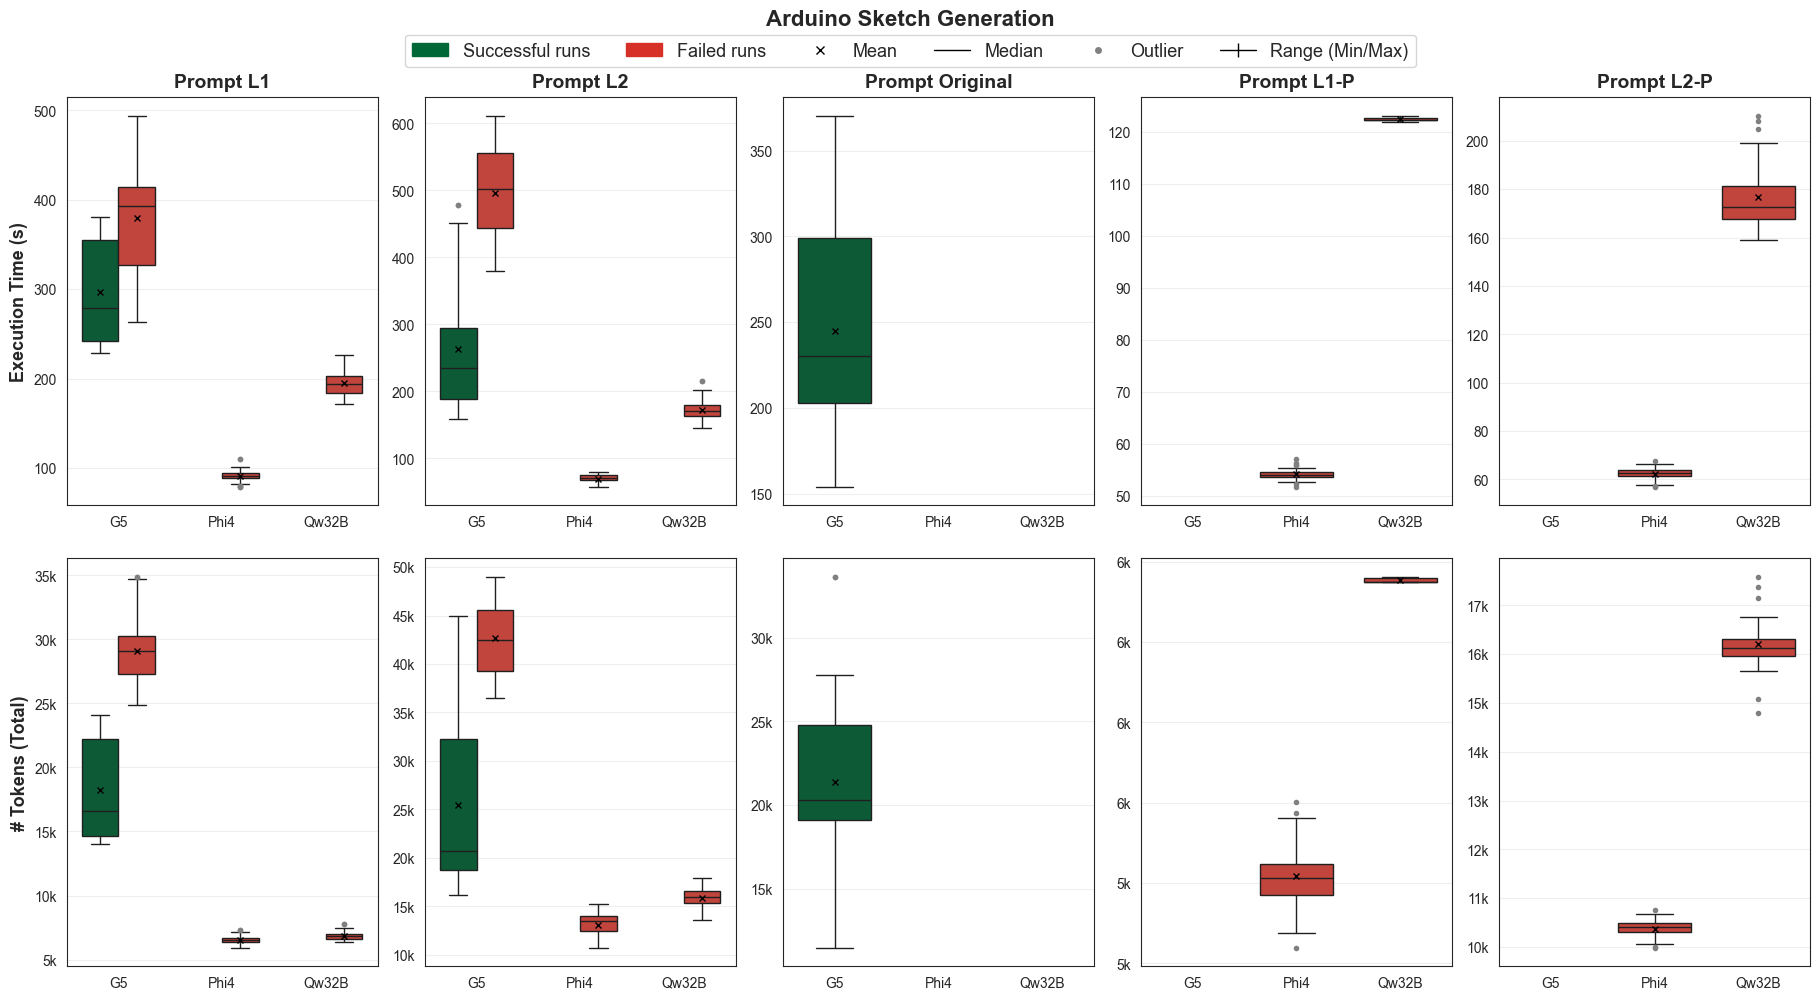

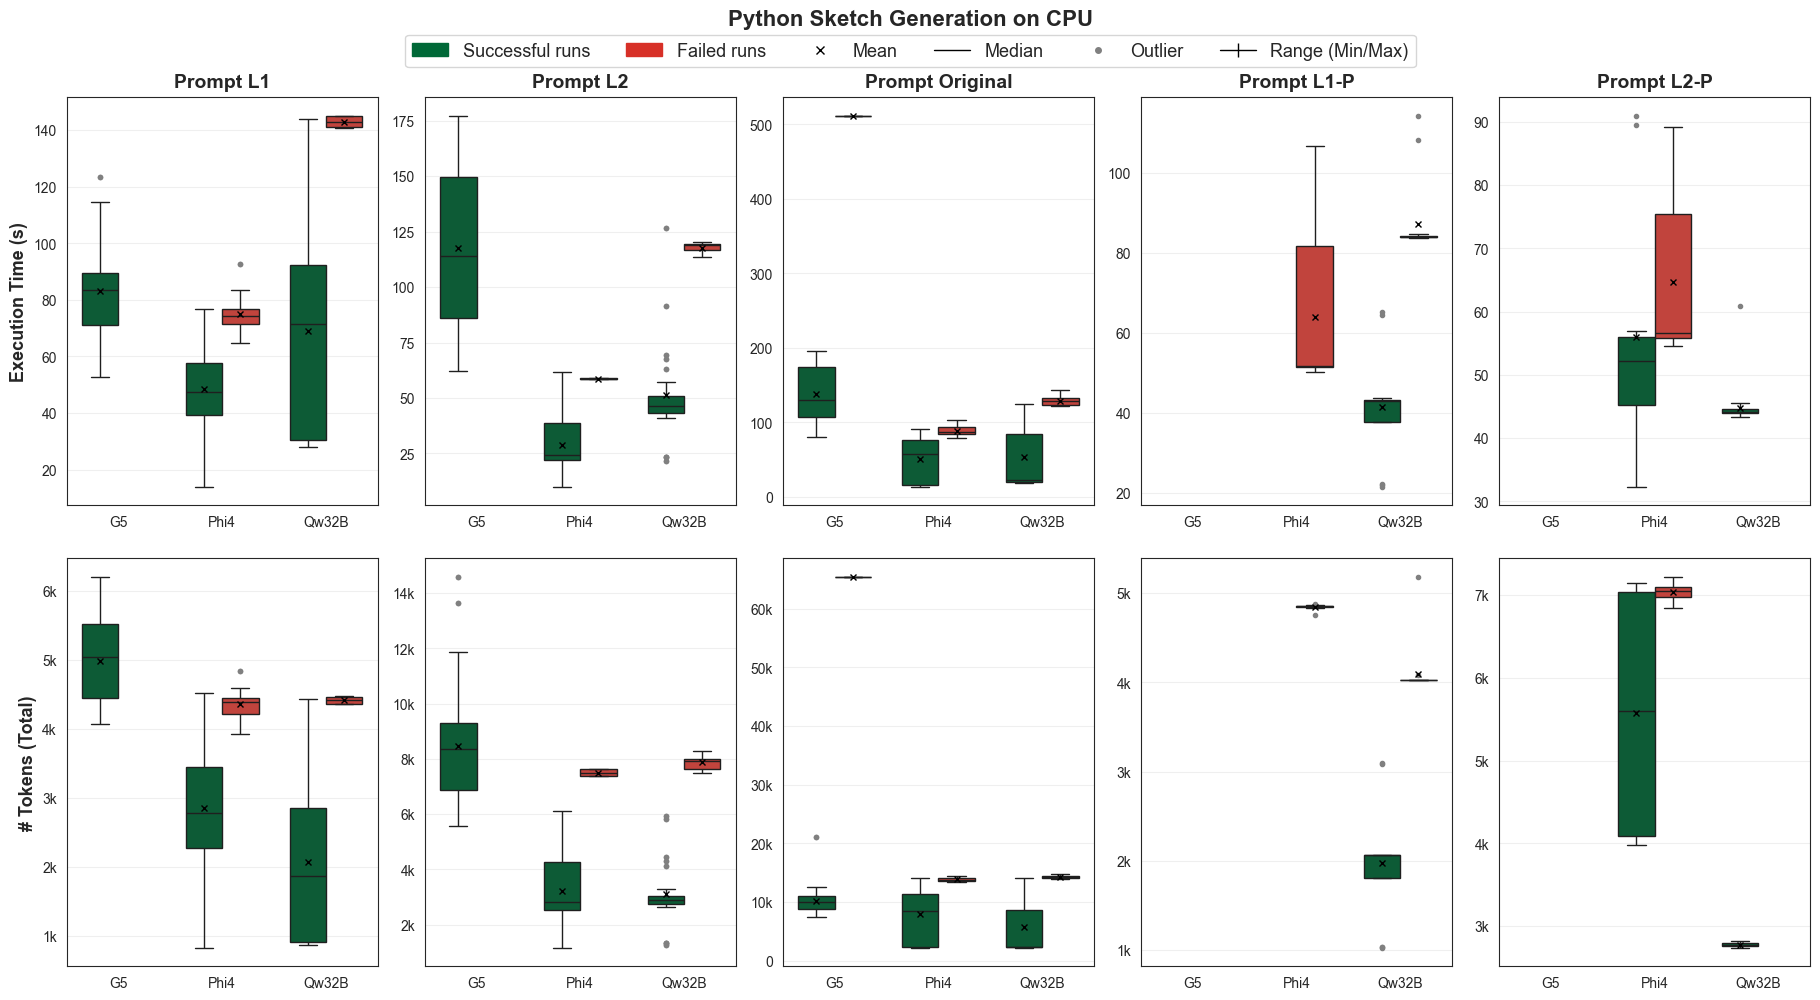

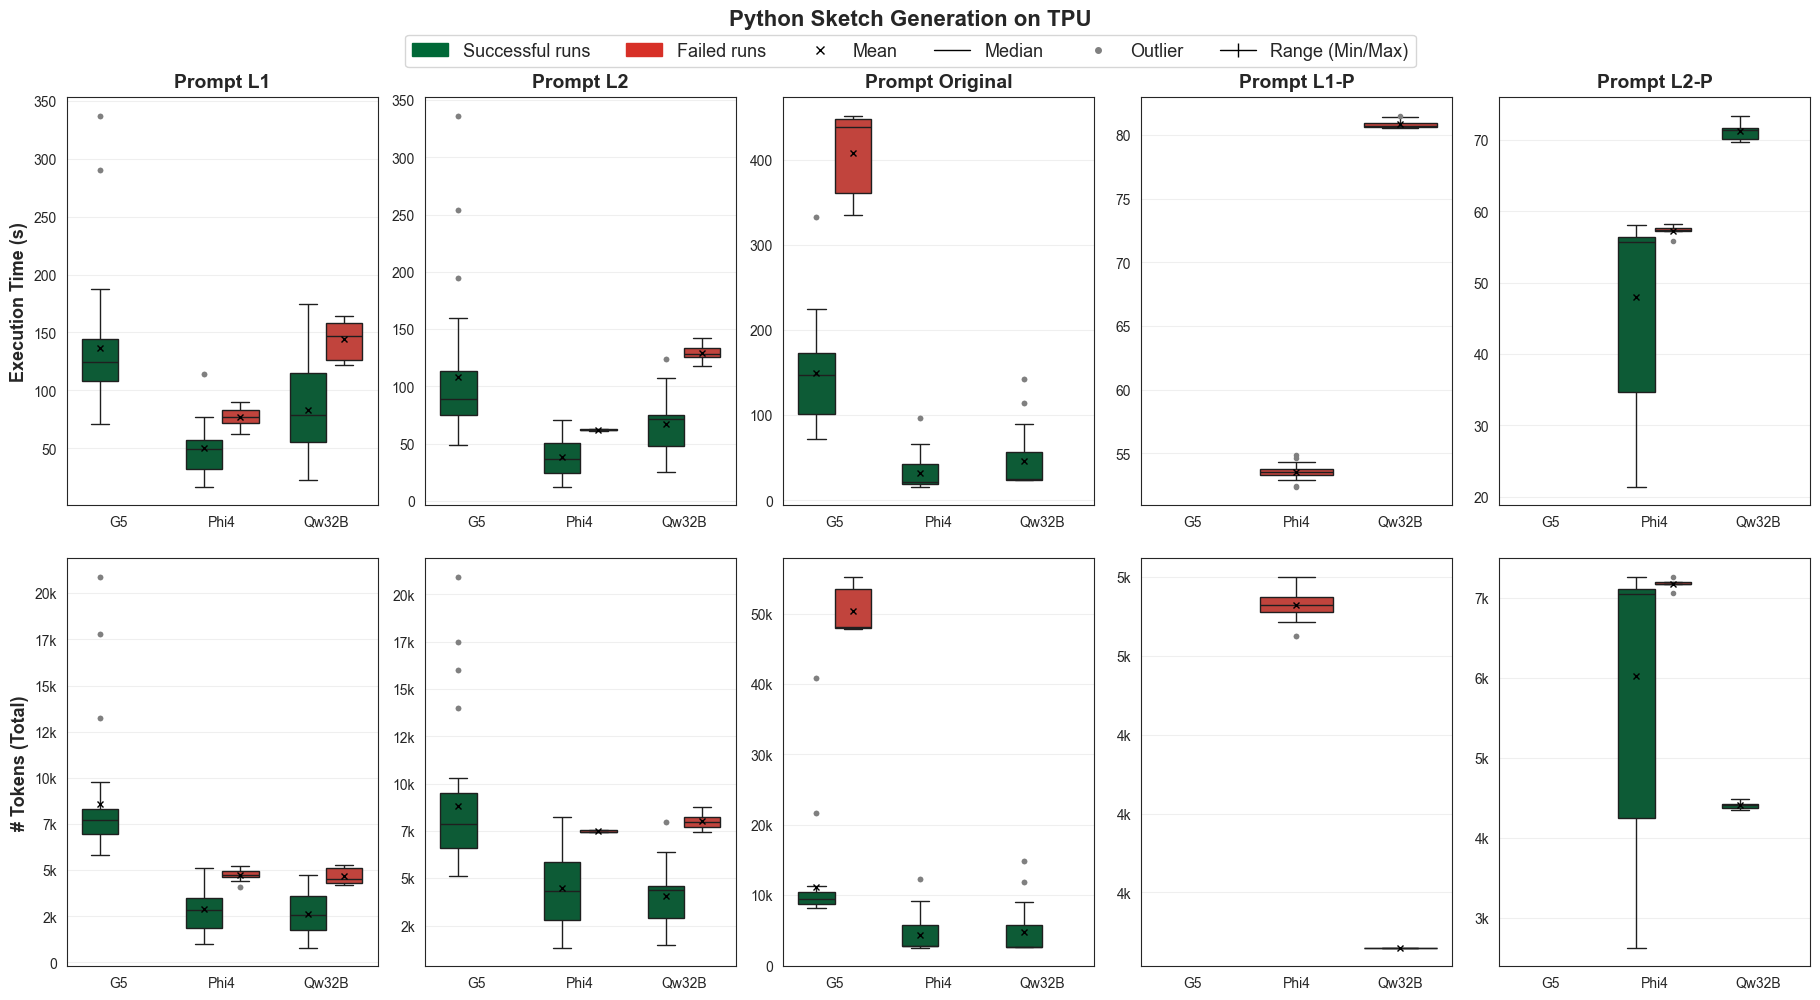

All plots generated successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D  # <--- Added for custom legend handles

# ==========================================
# 2. CONFIGURATION
# ==========================================
# Mappings

# Canonical labels and ordering (single source of truth)
MODEL_LABELS = {
    "gpt-5": "G5",
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "phi4": "Phi4",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "gemma3": "Ge3",
    "codestral": "Co22B",
    "codestral-p": "Co22B-p",
}

proc_titles = {
    'dp': 'Data Processing', 
    'mc': 'Model Conversion', 
    'sg': 'Arduino Sketch Generation', 
    "psg": "Python Sketch Generation on CPU", 
    "tpusg": "Python Sketch Generation on TPU",
}

PROCESSOR_LABELS = { 
    "dp": "DP",
    "mc": "MC",  
    "sg": "ArdSG",
    "psg": "PyCPU-SG", 
    "tpusg": "PyTPU-SG",
}

# Prompt type labels and ordering
PROMPT_TYPE_LABELS = {
    "abla-l1": "Prompt L1",
    "abla-l2": "Prompt L2",
    "original": "Prompt Original",
    "abla-1p": "Prompt L1-P",
    "abla-2p": "Prompt L2-P",
}

# Ordering & Styling
MODEL_ORDER_PREF = list(MODEL_LABELS.keys())
PROCESSOR_ORDER_PREF = ["sg", "psg", "tpusg"]  # Only the three processors we want to plot
PROMPT_TYPE_ORDER = ["abla-l1", "abla-l2", "original", "abla-1p", "abla-2p"]

# Filter to only models that exist in the data and map to display names
models_in_data = [m for m in MODEL_ORDER_PREF if m in df['model'].unique()]
model_display_order = [MODEL_LABELS[m] for m in models_in_data]
 
palette = {'success': '#006837', 'failure': '#D73027'}

# Apply Map
df['model_display'] = df['model'].map(MODEL_LABELS)

# Metric Configuration
metrics = [
    {'col': 'latency',      'label': 'Execution Time (s)', 'fmt': None},
    {'col': 'total_tokens', 'label': '# Tokens (Total)',   'fmt': lambda x, p: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'}
]

# ==========================================
# 3. PLOTTING - One figure per processor
# ==========================================
sns.set_style("white")
plt.rcParams['font.family'] = 'Arial'

# Define Custom Legend Elements (once for all figures)
legend_elements = [
    plt.Rectangle((0,0), 1, 1, color=palette['success'], label='Successful runs'),
    plt.Rectangle((0,0), 1, 1, color=palette['failure'], label='Failed runs'),
    Line2D([0], [0], color='black', marker='x', linestyle='None', 
           markersize=6, label='Mean'),
    Line2D([0], [0], color='black', linewidth=1, linestyle='-', 
           label='Median'),
    Line2D([0], [0], color='gray', marker='o', linestyle='None', 
           markersize=4, label='Outlier'),
    Line2D([0], [0], color='black', linewidth=1, linestyle='-', 
           marker='|', markersize=10, label='Range (Min/Max)')
]

# Create a separate figure for each processor
for proc in PROCESSOR_ORDER_PREF:
    proc_data = df[df['processor'] == proc]
    
    if proc_data.empty:
        print(f"No data for processor: {proc}")
        continue
    
    # Filter prompt types that exist in this processor's data
    prompt_types_in_data = [pt for pt in PROMPT_TYPE_ORDER if pt in proc_data['prompt_type'].unique()]
    num_prompt_types = len(prompt_types_in_data)
    
    if num_prompt_types == 0:
        print(f"No prompt types found for processor: {proc}")
        continue
    
    # Create figure: 2 rows (metrics) x num_prompt_types columns
    fig, axes = plt.subplots(nrows=2, ncols=num_prompt_types, 
                             figsize=(4.5*num_prompt_types, 11))  # Increase from 6 to 7 for wider subplots
    
    # Handle case where there's only one prompt type (axes won't be 2D)
    if num_prompt_types == 1:
        axes = axes.reshape(-1, 1)
    
    plt.subplots_adjust(top=0.90, hspace=0.13, wspace=0.15)  # Increase wspace for more horizontal spacing
    
    # Add main title for the processor
    fig.suptitle(proc_titles.get(proc, proc), fontsize=16, weight='bold', y=0.98)
    
    # Iterate through prompt types (columns) and metrics (rows)
    for col_idx, prompt_type in enumerate(prompt_types_in_data):
        subset = proc_data[proc_data['prompt_type'] == prompt_type]
        
        for row_idx, metric in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            
            if subset.empty:
                ax.set_visible(False)
                continue

            # 1. Plot
            sns.boxplot(
                data=subset, x='model_display', y=metric['col'], hue='status',
                hue_order=['success', 'failure'], order=model_display_order,
                ax=ax, palette=palette,
                showmeans=True, 
                meanprops={"marker":"x", "markeredgecolor":"black", "markersize":5},
                flierprops={"marker":"o", "markersize":3, "markerfacecolor":"gray", "markeredgecolor":"gray"},
                width=0.7, linewidth=1.0
            )
            
            # 2. Clean up
            if ax.get_legend(): 
                ax.get_legend().remove()
            ax.set_xlabel("")
            ax.grid(axis='y', alpha=0.3)
            
            # 3. Styling
            # Y-label only on leftmost column
            ax.set_ylabel(metric['label'] if col_idx == 0 else "", fontweight='bold', fontsize=13)
            
            # Subplot title (prompt type) only on top row
            if row_idx == 0:
                ax.set_title(PROMPT_TYPE_LABELS.get(prompt_type, prompt_type), 
                           fontsize=14, weight='bold', pad=7)
            
            # Format y-axis if needed
            if metric['fmt']:
                ax.yaxis.set_major_formatter(FuncFormatter(metric['fmt']))
    
    # Add legend to each figure
    fig.legend(handles=legend_elements, loc='upper center', ncol=6, 
               bbox_to_anchor=(0.5, 0.965), fontsize=13, frameon=True)
    
    # Save figure
    plt.savefig(f"figs/box_{proc}_ablation.pdf", dpi=300, bbox_inches='tight')
    plt.show()

print("All plots generated successfully!")


In [3]:
# ==========================================
# EXPORT BOX PLOT STATISTICS
# ==========================================
# Calculate all statistics used in box plots for direct reproduction
# Including prompt_type as an additional grouping dimension

def calculate_boxplot_stats(group_data):
    """Calculate all box plot statistics for a group"""
    if len(group_data) == 0:
        return {
            'count': 0,
            'min': None,
            'q1': None,
            'median': None,
            'q3': None,
            'max': None,
            'mean': None,
            'iqr': None,
            'lower_whisker': None,
            'upper_whisker': None,
            'outliers': None,
            'n_outliers': 0
        }
    
    q1 = group_data.quantile(0.25)
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1
    
    # Calculate whiskers (1.5 * IQR rule used by matplotlib/seaborn)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Actual whisker positions (min/max within bounds)
    within_bounds = group_data[(group_data >= lower_bound) & (group_data <= upper_bound)]
    lower_whisker = within_bounds.min() if len(within_bounds) > 0 else group_data.min()
    upper_whisker = within_bounds.max() if len(within_bounds) > 0 else group_data.max()
    
    # Outliers (outside whisker bounds)
    outliers = group_data[(group_data < lower_bound) | (group_data > upper_bound)]
    
    return {
        'count': len(group_data),
        'min': group_data.min(),
        'q1': q1,
        'median': group_data.median(),
        'q3': q3,
        'max': group_data.max(),
        'mean': group_data.mean(),
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'outliers': outliers.tolist(),
        'n_outliers': len(outliers)
    }

# Initialize list to store all statistics
all_stats = []

# Calculate statistics for each metric
metrics_to_export = [
    {'col': 'latency', 'label': 'Execution Time (s)'},
    {'col': 'total_tokens', 'label': '# Tokens (Total)'}
]

for metric in metrics_to_export:
    metric_col = metric['col']
    
    # Group by processor, model, prompt_type, and status
    for processor in df['processor'].unique():
        for model in df['model'].unique():
            for prompt_type in df['prompt_type'].unique():
                for status in ['success', 'failure']:
                    # Filter data for this combination
                    subset = df[
                        (df['processor'] == processor) & 
                        (df['model'] == model) & 
                        (df['prompt_type'] == prompt_type) &
                        (df['status'] == status)
                    ][metric_col].dropna()
                    
                    # Calculate statistics
                    stats = calculate_boxplot_stats(subset)
                    
                    # Add grouping information
                    stats_record = {
                        'metric': metric_col,
                        'processor': processor,
                        'processor_label': PROCESSOR_LABELS.get(processor, processor),
                        'model': model,
                        'model_label': MODEL_LABELS.get(model, model),
                        'prompt_type': prompt_type,
                        'prompt_type_label': PROMPT_TYPE_LABELS.get(prompt_type, prompt_type),
                        'status': status,
                        **stats
                    }
                    
                    all_stats.append(stats_record)

# Create DataFrame from statistics
stats_df = pd.DataFrame(all_stats)

# Filter out rows with no data
stats_df = stats_df[stats_df['count'] > 0]

# Drop outliers column for cleaner CSV
stats_df_clean = stats_df.drop(columns=['outliers'])

# Export to single CSV file
output_file = 'cost-time_statistics_ablation.csv'
stats_df_clean.to_csv(output_file, index=False)
print(f"✔ Exported all box plot statistics to: {output_file}")
print(f"  Total records: {len(stats_df_clean)}")
print(f"  Metrics included: latency, total_tokens")

# Display summary
print("\n" + "="*60)
print("STATISTICS SUMMARY")
print("="*60)
print(f"Metrics: {', '.join([m['col'] for m in metrics_to_export])}")
print(f"Processors: {', '.join(stats_df_clean['processor'].unique())}")
print(f"Models: {', '.join(stats_df_clean['model'].unique())}")
print(f"Prompt types: {', '.join(stats_df_clean['prompt_type'].unique())}")
print(f"Status values: {', '.join(stats_df_clean['status'].unique())}")
print("\nColumns in exported CSV:")
for col in stats_df_clean.columns:
    print(f"  - {col}")
print("="*60)

# Display sample of statistics
print("\nSample statistics (first few rows):")
display(stats_df_clean.head(10))

✔ Exported all box plot statistics to: cost-time_statistics_ablation.csv
  Total records: 108
  Metrics included: latency, total_tokens

STATISTICS SUMMARY
Metrics: latency, total_tokens
Processors: sg, psg, tpusg
Models: gpt-5, phi4, qwen32
Prompt types: abla-l1, abla-l2, original, abla-1p, abla-2p
Status values: success, failure

Columns in exported CSV:
  - metric
  - processor
  - processor_label
  - model
  - model_label
  - prompt_type
  - prompt_type_label
  - status
  - count
  - min
  - q1
  - median
  - q3
  - max
  - mean
  - iqr
  - lower_whisker
  - upper_whisker
  - n_outliers

Sample statistics (first few rows):


,metric,processor,processor_label,model,model_label,prompt_type,prompt_type_label,status,count,min,q1,median,q3,max,mean,iqr,lower_whisker,upper_whisker,n_outliers
0,latency,sg,ArdSG,gpt-5,G5,abla-l1,Prompt L1,success,6,228.95,241.4775,279.060,355.5000,380.98,296.330000,114.0225,228.95,380.98,0
1,latency,sg,ArdSG,gpt-5,G5,abla-l1,Prompt L1,failure,54,263.47,326.6575,392.850,414.4200,493.98,379.418519,87.7625,263.47,493.98,0
2,latency,sg,ArdSG,gpt-5,G5,abla-l2,Prompt L2,success,42,158.93,188.8400,235.160,294.1700,478.10,263.858095,105.3300,158.93,451.65,2
3,latency,sg,ArdSG,gpt-5,G5,abla-l2,Prompt L2,failure,18,379.25,443.7400,501.440,555.9600,611.41,495.557778,112.2200,379.25,611.41,0
4,latency,sg,ArdSG,gpt-5,G5,original,Prompt Original,success,60,154.13,202.6200,230.365,299.1300,370.24,244.700000,96.5100,154.13,370.24,0
11,latency,sg,ArdSG,phi4,Phi4,abla-l1,Prompt L1,failure,60,78.95,88.6200,91.485,94.1300,110.06,91.462000,5.5100,82.34,100.66,6
13,latency,sg,ArdSG,phi4,Phi4,abla-l2,Prompt L2,failure,22,57.63,67.3025,70.870,74.7400,79.65,69.872727,7.4375,57.63,79.65,0
17,latency,sg,ArdSG,phi4,Phi4,abla-1p,Prompt L1-P,failure,30,51.80,53.7400,54.110,54.5950,57.18,54.245000,0.8550,52.79,55.41,6
19,latency,sg,ArdSG,phi4,Phi4,abla-2p,Prompt L2-P,failure,30,56.98,61.2725,62.705,63.7625,67.50,62.243000,2.4900,57.84,66.32,3
21,latency,sg,ArdSG,qwen32,Qw32B,abla-l1,Prompt L1,failure,60,171.04,183.9000,194.380,203.0200,226.86,194.861000,19.1200,171.04,226.86,0
